# Synthetic Data Generation Using RAGAS - RAG Evaluation with LangSmith

In the following notebook we'll explore a use-case for RAGAS' synthetic testset generation workflow!



- 🤝 BREAKOUT ROOM #1
  1. Use RAGAS to Generate Synthetic Data

- 🤝 BREAKOUT ROOM #2
  1. Load them into a LangSmith Dataset
  2. Evaluate our RAG chain against the synthetic test data
  3. Make changes to our pipeline
  4. Evaluate the modified pipeline

SDG is a critical piece of the puzzle, especially for early iteration! Without it, it would not be nearly as easy to get high quality early signal for our application's performance.

Let's dive in!

# 🤝 BREAKOUT ROOM #1

## Task 1: Dependencies and API Keys

We'll need to install a number of API keys and dependencies, since we'll be leveraging a number of great technologies for this pipeline!

1. OpenAI's endpoints to handle the Synthetic Data Generation
2. OpenAI's Endpoints for our RAG pipeline and LangSmith evaluation
3. QDrant as our vectorstore
4. LangSmith for our evaluation coordinator!

Let's install and provide all the required information below!

## Dependencies and API Keys:

### NLTK Import

To prevent errors that may occur based on OS - we'll import NLTK and download the needed packages to ensure correct handling of data.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /Users/betsyberenback-
[nltk_data]     gold/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/betsyberenback-gold/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [2]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

We'll also want to set a project name to make things easier for ourselves.

In [3]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OpenAI's API Key!

In [4]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - which should hopefull be familiar at this point since it's our Use-Case Data!

Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [5]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Unrolled SDG

In [6]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

Next, we're going to instantiate our Knowledge Graph.

This graph will contain N number of nodes that have M number of relationships. These nodes and relationships (AKA "edges") will define our knowledge graph and be used later to construct relevant questions and responses.

In [7]:
from ragas.testset.graph import KnowledgeGraph

kg = KnowledgeGraph()
kg

KnowledgeGraph(nodes: 0, relationships: 0)

The first step we're going to take is to simply insert each of our full documents into the graph. This will provide a base that we can apply transformations to.

In [8]:
from ragas.testset.graph import Node, NodeType

### NOTICE: We're using a subset of the data for this example - this is to keep costs/time down.
for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )
kg

KnowledgeGraph(nodes: 64, relationships: 0)

Now, we'll apply the *default* transformations to our knowledge graph. This will take the nodes currently on the graph and transform them based on a set of [default transformations](https://docs.ragas.io/en/latest/references/transforms/#ragas.testset.transforms.default_transforms).

These default transformations are dependent on the corpus length, in our case:

- Producing Summaries -> produces summaries of the documents
- Extracting Headlines -> finding the overall headline for the document
- Theme Extractor -> extracts broad themes about the documents

It then uses cosine-similarity and heuristics between the embeddings of the above transformations to construct relationships between the nodes.

In [9]:
from ragas.testset.transforms import default_transforms, apply_transforms

transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
kg

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/38 [00:00<?, ?it/s]

Property 'summary' already exists in node '4273be'. Skipping!
Property 'summary' already exists in node '2cdc43'. Skipping!
Property 'summary' already exists in node '3bdfa3'. Skipping!
Property 'summary' already exists in node '5aa511'. Skipping!
Property 'summary' already exists in node '0b5e6a'. Skipping!
Property 'summary' already exists in node 'd63431'. Skipping!
Property 'summary' already exists in node '677402'. Skipping!
Property 'summary' already exists in node 'bd7e39'. Skipping!
Property 'summary' already exists in node 'f0d69c'. Skipping!
Property 'summary' already exists in node 'd1dda0'. Skipping!
Property 'summary' already exists in node 'ea31b0'. Skipping!
Property 'summary' already exists in node '1ec4d7'. Skipping!
Property 'summary' already exists in node '251134'. Skipping!
Property 'summary' already exists in node 'a1bd16'. Skipping!
Property 'summary' already exists in node 'd7f9a9'. Skipping!
Property 'summary' already exists in node 'cc6b94'. Skipping!
Property

Applying CustomNodeFilter:   0%|          | 0/8 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/48 [00:00<?, ?it/s]

Property 'summary_embedding' already exists in node '0b5e6a'. Skipping!
Property 'summary_embedding' already exists in node 'd63431'. Skipping!
Property 'summary_embedding' already exists in node 'f0d69c'. Skipping!
Property 'summary_embedding' already exists in node 'ea31b0'. Skipping!
Property 'summary_embedding' already exists in node '2cdc43'. Skipping!
Property 'summary_embedding' already exists in node '4273be'. Skipping!
Property 'summary_embedding' already exists in node '677402'. Skipping!
Property 'summary_embedding' already exists in node '3bdfa3'. Skipping!
Property 'summary_embedding' already exists in node 'bd7e39'. Skipping!
Property 'summary_embedding' already exists in node 'd1dda0'. Skipping!
Property 'summary_embedding' already exists in node '5aa511'. Skipping!
Property 'summary_embedding' already exists in node '1ec4d7'. Skipping!
Property 'summary_embedding' already exists in node '1ef139'. Skipping!
Property 'summary_embedding' already exists in node 'cc6b94'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

KnowledgeGraph(nodes: 86, relationships: 711)

We can save and load our knowledge graphs as follows.

In [10]:
kg.save("usecase_data_kg.json")
usecase_data_kg = KnowledgeGraph.load("usecase_data_kg.json")
usecase_data_kg

KnowledgeGraph(nodes: 86, relationships: 711)

Using our knowledge graph, we can construct a "test set generator" - which will allow us to create queries.

In [11]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=usecase_data_kg)

However, we'd like to be able to define the kinds of queries we're generating - which is made simple by Ragas having pre-created a number of different "QuerySynthesizer"s.

Each of these Synthetsizers is going to tackle a separate kind of query which will be generated from a scenario and a persona.

In essence, Ragas will use an LLM to generate a persona of someone who would interact with the data - and then use a scenario to construct a question from that data and persona.

In [12]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

#### ❓ Question #1:

What are the three types of query synthesizers doing? Describe each one in simple terms.

ANSWER ✅

The above code defines the distribution of query synthesizers that generate different kinds of questions or scenarios for testing.
There are three types, each designed to produce a unique style of question — helping evaluate different levels of reasoning and information retrieval strategies.

1.) SingleHopSpecific:
These are straightforward questions that can be answered with one search or reasoning step. The answer is clear and factual.
Example: “What is a lamp?” — it’s a direct question that doesn’t require breaking down the problem.

2.) MultiHopAbstract:
These questions require understanding, connecting, and reasoning multiple ideas or sub-questions, focusing on concepts or causes rather than direct facts. They tend to be broader or more conversational.
Example: “What started the Civil War?” — the system has to reason through multiple historical factors and interpret causes.

3.) MultiHopSpecific:
These also require multiple reasoning steps, but the final answer is concrete and well-defined. The model must combine several pieces of information to find a precise result.
Example: “When did the Civil War occur on Virginia soil?” — it has to identify the event, locate it in Virginia, and determine the specific date.

Finally, we can use our `TestSetGenerator` to generate our testset!

In [41]:
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,what happen in july 2025,[Introduction ChatGPT launched in November 202...,"By July 2025, 18 billion messages were being s...",single_hop_specifc_query_synthesizer
1,What is the significance of June 2024 in the c...,[Table 1: ChatGPT daily message counts (millio...,The context reports that the 26th of June 2024...,single_hop_specifc_query_synthesizer
2,What are the SOC2 codes 17 used for in relatio...,[Figure 23 presents variation in ChatGPT usage...,The context mentions SOC2 codes 17 as part of ...,single_hop_specifc_query_synthesizer
3,"As an AI Adoption Strategist, how does the dat...",[Conclusion This paper studies the rapid growt...,"The data indicates that as of July 2025, about...",single_hop_specifc_query_synthesizer
4,How do the changes in user behavior and prefer...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,The data shows that from June 2024 to June 202...,multi_hop_abstract_query_synthesizer
5,How do ChatGPT's usage patterns for practical ...,[<1-hop>\n\nConclusion This paper studies the ...,ChatGPT's most common conversation topics are ...,multi_hop_abstract_query_synthesizer
6,"How does the rapid growth of ChatGPT, with its...",[<1-hop>\n\nConclusion This paper studies the ...,"The rapid growth of ChatGPT, which by July 202...",multi_hop_abstract_query_synthesizer
7,"Given that by July 2025, over 700 million user...",[<1-hop>\n\nConclusion This paper studies the ...,"By July 2025, ChatGPT had achieved a remarkabl...",multi_hop_specific_query_synthesizer
8,"H0w many usrs of chatgpt r there, and how many...",[<1-hop>\n\nConclusion This paper studies the ...,"According to the context, by July 2025, ChatGP...",multi_hop_specific_query_synthesizer
9,Based on the rapid growth of ChatGPT usage in ...,[<1-hop>\n\nConclusion This paper studies the ...,"The context indicates that by June 2025, non-w...",multi_hop_specific_query_synthesizer


### Abstracted SDG (Recommended Approach)

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.

**Note**: This approach is more robust and handles clustering issues automatically, making it the recommended method for most use cases.



In [42]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/38 [00:00<?, ?it/s]

Property 'summary' already exists in node '374b7a'. Skipping!
Property 'summary' already exists in node '3ee593'. Skipping!
Property 'summary' already exists in node '6b42cc'. Skipping!
Property 'summary' already exists in node '5453c5'. Skipping!
Property 'summary' already exists in node 'ed8627'. Skipping!
Property 'summary' already exists in node '38ebe7'. Skipping!
Property 'summary' already exists in node '658914'. Skipping!
Property 'summary' already exists in node '14aeae'. Skipping!
Property 'summary' already exists in node '8a6945'. Skipping!
Property 'summary' already exists in node '1bf465'. Skipping!
Property 'summary' already exists in node '4ea17f'. Skipping!
Property 'summary' already exists in node 'feda60'. Skipping!
Property 'summary' already exists in node '793c8c'. Skipping!
Property 'summary' already exists in node 'e1de58'. Skipping!
Property 'summary' already exists in node 'ddcfc3'. Skipping!
Property 'summary' already exists in node '8f587c'. Skipping!
Property

...

Property 'summary_embedding' already exists in node 'ed8627'. Skipping!
Property 'summary_embedding' already exists in node '5453c5'. Skipping!
Property 'summary_embedding' already exists in node '3ee593'. Skipping!
Property 'summary_embedding' already exists in node '8a6945'. Skipping!
Property 'summary_embedding' already exists in node '6b42cc'. Skipping!
Property 'summary_embedding' already exists in node '374b7a'. Skipping!
Property 'summary_embedding' already exists in node '1bf465'. Skipping!
Property 'summary_embedding' already exists in node '14aeae'. Skipping!
Property 'summary_embedding' already exists in node '4ea17f'. Skipping!
Property 'summary_embedding' already exists in node '658914'. Skipping!
Property 'summary_embedding' already exists in node '38ebe7'. Skipping!
Property 'summary_embedding' already exists in node 'feda60'. Skipping!
Property 'summary_embedding' already exists in node '793c8c'. Skipping!
Property 'summary_embedding' already exists in node 'e1de58'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [43]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,"Considering the rapid adoption of ChatGPT, wit...",[Introduction ChatGPT launched in November 202...,"By July 2025, 18 billion messages were being s...",single_hop_specifc_query_synthesizer
1,How is ChatGPT used for work-related purposes ...,[Table 1: ChatGPT daily message counts (millio...,Nearly 80% of all ChatGPT usage falls into thr...,single_hop_specifc_query_synthesizer
2,How are nonprofessional occupations characteri...,[Figure 23 presents variation in ChatGPT usage...,Figure 23 reports that users in all nonprofess...,single_hop_specifc_query_synthesizer
3,How many messages were sent in total when Chat...,[Conclusion This paper studies the rapid growt...,"By July 2025, ChatGPT had been used weekly by ...",single_hop_specifc_query_synthesizer
4,H0w do work activitees and core job tasks diff...,[<1-hop>\n\nFigure 23 presents variation in Ch...,The context shows that users in highly paid pr...,multi_hop_abstract_query_synthesizer
5,How does ChatGPT usage vary across different o...,[<1-hop>\n\nFigure 23 presents variation in Ch...,Figure 23 shows that ChatGPT usage differs sig...,multi_hop_abstract_query_synthesizer
6,How do ChatGPT usage patterns vary by occupati...,[<1-hop>\n\nFigure 23 presents variation in Ch...,The data shows that ChatGPT usage varies signi...,multi_hop_abstract_query_synthesizer
7,H0w do the limiations and diffrences in AI usa...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,The data indicates that while practical guidan...,multi_hop_abstract_query_synthesizer
8,how many messages 18 billion and 2.5 billion a...,[<1-hop>\n\nConclusion This paper studies the ...,"According to the context, by July 2025, ChatGP...",multi_hop_specific_query_synthesizer
9,Considering the rapid growth of ChatGPT since ...,[<1-hop>\n\nConclusion This paper studies the ...,The usage pattern of ChatGPT has evolved signi...,multi_hop_specific_query_synthesizer


We'll need to provide our LangSmith API key, and set tracing to "true".

# 🤝 BREAKOUT ROOM #2

## Task 4: LangSmith Dataset

Now we can move on to creating a dataset for LangSmith!

First, we'll need to create a dataset on LangSmith using the `Client`!

We'll name our Dataset to make it easy to work with later.

In [45]:
from langsmith import Client

client = Client()

dataset_name = "Use Case Synthetic Data - AIE8_v3"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Synthetic Data for Use Cases"
)

We'll iterate through the RAGAS created dataframe - and add each example to our created dataset!

> NOTE: We need to conform the outputs to the expected format - which in this case is: `question` and `answer`.

In [46]:
for data_row in dataset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

## Basic RAG Chain

Time for some RAG!


In [47]:
rag_documents = docs

To keep things simple, we'll just use LangChain's recursive character text splitter!


In [48]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

We'll create our vectorstore using OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) embedding model.

In [49]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

As usual, we will power our RAG application with Qdrant!

In [50]:
from langchain_community.vectorstores import Qdrant

vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG"
)

In [51]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

To get the "A" in RAG, we'll provide a prompt.

In [52]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

As is usual: We'll be using `gpt-4.1-mini` for our RAG!

In [53]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

Finally, we can set-up our RAG LCEL chain!

In [54]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain.schema import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [55]:
rag_chain.invoke({"question" : "What are people doing with AI these days?"})

'Based on the provided context, people are using AI, particularly generative AI like ChatGPT, in a variety of ways both at work and outside of work. AI is performing workplace tasks by either augmenting or automating human labor. Users engage with AI to produce writing, software code, spreadsheets, and other digital products, distinguishing generative AI from traditional web search engines. People also use AI with different user intents classified as Asking (seeking information or advice), Doing (producing output or completing tasks), and Expressing (self-expression). Additionally, AI serves as a co-worker producing output or as a co-pilot improving human problem-solving productivity. Common uses include information seeking, writing assistance, coding, data analysis, and creative activities like games and role play. There is also mention of therapy/companionship as a prevalent use case. Overall, AI is highly flexible and integrated into both professional and personal activities for a r

## LangSmith Evaluation Set-up

We'll use OpenAI's GPT-4.1 as our evaluation LLM for our base Evaluators.

In [56]:
eval_llm = ChatOpenAI(model="gpt-4.1")

We'll be using a number of evaluators - from LangSmith provided evaluators, to a few custom evaluators!

In [57]:
from langsmith.evaluation import LangChainStringEvaluator, evaluate

qa_evaluator = LangChainStringEvaluator("qa", config={"llm" : eval_llm})

labeled_helpfulness_evaluator = LangChainStringEvaluator(
    "labeled_criteria",
    config={
        "criteria": {
            "helpfulness": (
                "Is this submission helpful to the user,"
                " taking into account the correct reference answer?"
            )
        },
        "llm" : eval_llm
    },
    prepare_data=lambda run, example: {
        "prediction": run.outputs["output"],
        "reference": example.outputs["answer"],
        "input": example.inputs["question"],
    }
)

dopeness_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria": {
            "dopeness": "Is this response dope, lit, cool, or is it just a generic response?",
        },
        "llm" : eval_llm
    }
)

#### 🏗️ Activity #2:

Highlight what each evaluator is evaluating.

ANSWER ✅
- `qa_evaluator`: Evaluates the quality and correctness of the Question Answering (QA) response using a built-in, off-the-shelf LangChain evaluation template.

- `labeled_helpfulness_evaluator`: Evaluates how helpful the response is to the user by comparing it against a custom user-defined criterion — “Is this submission helpful to the user?”

- `dopeness_evaluator`: A custom evaluator that checks if the response is original, engaging, and has a unique style or “dopeness,” as defined by the given criteria.


## LangSmith Evaluation

In [58]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'crazy-place-78' at:
https://smith.langchain.com/o/bf3a953b-d5ae-479e-b06a-74d94431c40b/datasets/e378642e-6b1d-48ea-9b4b-2acd0fda9f0b/compare?selectedSessions=5f67f724-b8ed-4095-a25b-5bf8aecb9728




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,"How do Handa et al., 2025, and Handa et al. re...","The context mentions Handa et al., 2025, in re...",None,"Handa et al., 2025, provide detailed analysis ...",0,0,0,2.987420,7ebdaa51-fa32-4830-91e1-f044c2ce88b7,44649b74-3e4b-4367-876a-841da71f103e
1,"Based on Handa et al., 2025, how does the grow...","Based on the context, the growth in ChatGPT's ...",None,"According to the context, while most ChatGPT u...",1,1,0,2.365636,d577943c-0396-49f6-bd53-44bd5870d943,ff87fb81-4c05-4780-9203-9c21b06f33e7
2,Considering the rapid growth of ChatGPT since ...,"Since its launch in November 2022, ChatGPT exp...",None,The usage pattern of ChatGPT has evolved signi...,1,1,0,5.866934,2337ff2f-a3aa-4f06-ba62-17997e99138a,05cd99b2-4d1b-46df-b99e-e3a77cef15e4
3,how many messages 18 billion and 2.5 billion a...,Based on the provided context:\n\n- By July 20...,None,"According to the context, by July 2025, ChatGP...",1,1,0,4.709146,d09eeed5-5c49-458a-bbc5-09fa2a236151,499e5953-11a9-44a8-94a8-405088d11525
4,H0w do the limiations and diffrences in AI usa...,The data shows that the share of messages rela...,None,The data indicates that while practical guidan...,1,0,0,6.649285,861fdc46-9640-4c6b-b37d-fd340d3bdce1,612fdfd6-7141-4d2b-a91e-a77511afdabc
5,How do ChatGPT usage patterns vary by occupati...,Based on the provided context:\n\n**Variation ...,None,The data shows that ChatGPT usage varies signi...,1,1,0,12.386431,bdf4a54e-c7ea-4fea-a8d4-8c97f35b168b,1f22975d-afc1-47f6-a692-f8d64050de60
6,How does ChatGPT usage vary across different o...,Based on the provided context from the documen...,None,Figure 23 shows that ChatGPT usage differs sig...,1,0,0,6.604702,91759c41-1b2b-40e5-aa71-48cf4a381f2a,b2c593d2-4d61-4328-92d4-b2ac6038d8a4
7,H0w do work activitees and core job tasks diff...,"Based on the provided context, work activities...",None,The context shows that users in highly paid pr...,1,1,0,5.674307,db025390-a464-46f1-96a0-c263cf6a8662,442d5b89-5702-4fdc-b1d3-c429c416a012
8,How many messages were sent in total when Chat...,"By July 2025, when ChatGPT had been used weekl...",None,"By July 2025, ChatGPT had been used weekly by ...",1,1,0,3.465700,64fc3e06-424c-4152-bef8-e7c1eab36484,6bace437-4bae-4416-b5af-e2184478fa7f
9,How are nonprofessional occupations characteri...,Nonprofessional occupations—including administ...,None,Figure 23 reports that users in all nonprofess...,1,1,0,2.859888,45986458-a6f7-4053-bced-44d61d23627b,008546f8-c616-42f8-b5d9-e72e3a403978


## Dope-ifying Our Application

We'll be making a few changes to our RAG chain to increase its performance on our SDG evaluation test dataset!

- Include a "dope" prompt augmentation
- Use larger chunks
- Improve the retriever model to: `text-embedding-3-large`

Let's see how this changes our evaluation!

In [59]:
DOPENESS_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Make your answer rad, ensure high levels of dopeness. Do not be generic, or give generic responses.

Context: {context}
Question: {question}
"""

dopeness_rag_prompt = ChatPromptTemplate.from_template(DOPENESS_RAG_PROMPT)

In [60]:
rag_documents = docs

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

#### ❓Question #2:

Why would modifying our chunk size modify the performance of our application?

ANSWER ✅

Modifying the chunk size affects the performance and accuracy of a RAG application because it changes how much information the model has access to when answering a query.

- If chunks are too small, important context can be spread across multiple chunks. The retriever might only pull some of them, causing loss of information and leading to incomplete or noisy answers. Having many small chunks can also overwhelm the LLM — it must sift through more pieces, increasing confusion and retrieval noise. Overlap techniques can help preserve context and relevance, but they increase the total number of embeddings, which raises time and cost.

 - If chunks are too large, more context is captured within each chunk (increasing the chance the full answer is inside one), but it can also introduce irrelevant text. This reduces precision, makes retrieval less focused, and can slow processing due to larger payloads and context window limitations.

Overall, adjusting chunk size impacts retrieval recall, context precision, accuracy, and runtime efficiency. Often choosing the right chunking strategy depends on the type of document or purpose — for example, splitting by paragraph, sentence, or section boundaries can better preserve meaning depending on the content structure.

In [62]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

#### ❓Question #3:

Why would modifying our embedding model modify the performance of our application?

ANSWER ✅

Similar to choosing the correct chunk size, selecting an embedding model directly affects the application’s accuracy, speed, and cost. In this case, we’re using text-embedding-3-large, which offers higher accuracy and better semantic understanding — it can capture more subtle relationships and complex contexts due to its larger vector dimensions. This makes it ideal for complex queries, but it comes with tradeoffs: higher cost, larger storage requirements, greater computational demand, and slightly slower performance. A smaller model (such as text-embedding-3-small) is faster, more cost-efficient, and requires less compute and storage. It’s better suited for simpler tasks or real-time applications where speed and efficiency are prioritized over deep semantic precision. Overall, changing the embedding model impacts the semantic richness and retrieval accuracy of results, with tradeoffs in cost, speed, and computational requirements.



In [63]:
vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG Docs"
)

In [64]:
retriever = vectorstore.as_retriever()

Setting up our new and improved DOPE RAG CHAIN.

In [65]:
dopeness_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | dopeness_rag_prompt | llm | StrOutputParser()
)

Let's test it on the same output that we saw before.

In [66]:
dopeness_rag_chain.invoke({"question" : "How are people using AI to make money?"})

"Alright, strap in for some next-level insight! People are cashing in on AI, not just by letting it do their grunt work, but by turning it into a powerhouse advisor and research sidekick. According to the dopest findings in the context, ChatGPT is boosting worker output by leveling up decision-making quality—especially in knowledge-heavy gigs. Instead of just automating tasks, AI flexes its smarts by providing decision support that amps up productivity in careers where every smart choice counts. So, folks are basically making money by harnessing AI as their ultra-savvy partner in crime, not just a tool that punches the clock for them. This moves the needle in industries where sharp judgment is gold, making AI an income multiplier through brainpower augmentation. That's how AI is making it rain!"

Finally, we can evaluate the new chain on the same test set!

In [67]:
evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'aching-cod-25' at:
https://smith.langchain.com/o/bf3a953b-d5ae-479e-b06a-74d94431c40b/datasets/e378642e-6b1d-48ea-9b4b-2acd0fda9f0b/compare?selectedSessions=339b3fef-b771-4eec-8873-42a3fec8e704




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,"How do Handa et al., 2025, and Handa et al. re...","Yo, here’s the lowdown with mad style: Handa e...",None,"Handa et al., 2025, provide detailed analysis ...",1,1,1,3.644065,7ebdaa51-fa32-4830-91e1-f044c2ce88b7,ac09952a-61f1-4fc4-a82e-231e3ab92b96
1,"Based on Handa et al., 2025, how does the grow...","Yo, check this out: Handa et al., 2025 drop so...",None,"According to the context, while most ChatGPT u...",1,1,1,4.821754,d577943c-0396-49f6-bd53-44bd5870d943,05a9d9ae-33b9-4a43-9bd0-0a737758621e
2,Considering the rapid growth of ChatGPT since ...,"Alright, strap in — because the evolution of C...",None,The usage pattern of ChatGPT has evolved signi...,1,1,1,10.354209,2337ff2f-a3aa-4f06-ba62-17997e99138a,1858fc69-9bfb-4a24-a76b-4027a892754b
3,how many messages 18 billion and 2.5 billion a...,"Alright, let’s blaze through the data like a b...",None,"According to the context, by July 2025, ChatGP...",1,0,1,5.333616,d09eeed5-5c49-458a-bbc5-09fa2a236151,05976f6b-6a7f-4e37-af92-fb63201cef2a
4,H0w do the limiations and diffrences in AI usa...,"Oh, let’s unpack this AI saga with some seriou...",None,The data indicates that while practical guidan...,1,0,1,5.777676,861fdc46-9640-4c6b-b37d-fd340d3bdce1,e1bcb138-834d-4a62-b1e2-f8fb33805a3b
5,How do ChatGPT usage patterns vary by occupati...,"Alright, let’s drop some knowledge bombs on ho...",None,The data shows that ChatGPT usage varies signi...,1,0,1,7.936671,bdf4a54e-c7ea-4fea-a8d4-8c97f35b168b,e8c956ae-c2d8-43f8-b895-74ecbf35d89b
6,How does ChatGPT usage vary across different o...,"Yo, buckle up — here’s the lowdown on how Chat...",None,Figure 23 shows that ChatGPT usage differs sig...,1,1,1,6.358750,91759c41-1b2b-40e5-aa71-48cf4a381f2a,08f4b623-477c-42a5-8e93-2401414d7767
7,H0w do work activitees and core job tasks diff...,"Yo, here’s the wicked deep dive on how work ac...",None,The context shows that users in highly paid pr...,1,1,1,6.814924,db025390-a464-46f1-96a0-c263cf6a8662,0fdd494b-a904-4490-9111-6073b9485345
8,How many messages were sent in total when Chat...,"Alright, here’s the straight-up cosmic scoop: ...",None,"By July 2025, ChatGPT had been used weekly by ...",0,0,1,3.575418,64fc3e06-424c-4152-bef8-e7c1eab36484,ee0e9a8e-c19a-47fa-b3d9-5c4e04afbcce
9,How are nonprofessional occupations characteri...,"Alright, buckle up — here’s the lowdown on how...",None,Figure 23 reports that users in all nonprofess...,1,1,1,6.119570,45986458-a6f7-4053-bced-44d61d23627b,422518cb-054a-4a8a-8305-5c5a664a91e4


#### 🏗️ Activity #3:

Provide a screenshot of the difference between the two chains, and explain why you believe certain metrics changed in certain ways.













ANSWER ✅ 

In order to understand the evaluation results, it is important to first recognize the differences between the two RAG chains. RAG 1 (baseline) uses smaller chunks (500 tokens with 50-token overlap) and the text-embedding-3-small model. Its prompt is straightforward and factual, instructing the model to answer questions based solely on the provided context. This setup is generally faster for typical queries. RAG 2 (enhanced / “dope”) adds a stylistic instruction to make answers engaging and non-generic, while still maintaining factual accuracy and using only the context. It uses larger chunks (1000 tokens with 50-token overlap) and the text-embedding-3-large model, which preserves more context and improves semantic retrieval. Both chains use the same LLM (gpt-4.1-mini) and the same synthetic dataset with identical question distributions.

In terms of performance, RAG 2 performed better in correctness, scoring 11/12 correct answers (92%) compared to 10/12 (83%) for RAG 1. For the dopeness metric, RAG 2 achieved 12/12, as expected given the prompt, whereas RAG 1 scored 0/12. Helpfulness was equal for both (8 “yes” and 4 “no”). Although in RAG 2 some creative answers were harder to understand (too dope for their own good), both chains had answers drift from the context due to mismatched examples, contradictory quantitative values, overgeneralization, or lack of clarity and formatting.

Regarding latency, RAG 1 had lower p50 latency due to its smaller chunks and embedding model, making it faster for typical queries. However, RAG 2 had lower p99 latency, indicating better performance on tail queries or the most complex retrievals thanks to larger embeddings and context preservation.

Overall, RAG 2 is more accurate and produces higher-quality, engaging answers. However, depending on the use case—such as prioritizing speed or cost—RAG 1 may still be preferable. This highlights the trade-off between accuracy, latency, and resource usage when designing RAG pipelines.For example, is having 1 extra answer better in trade of a lot more compute? 



⬇️ Screenshots below ⬇️

Found 3 PNG files in the data folder:
  - RAG1_Original.png
  - Comparision.png
  - RAG2_Dope.png

DISPLAYING PNG FILES:

📸 1. Rag1 Original
   File: RAG1_Original.png
   Path: data/RAG1_Original.png


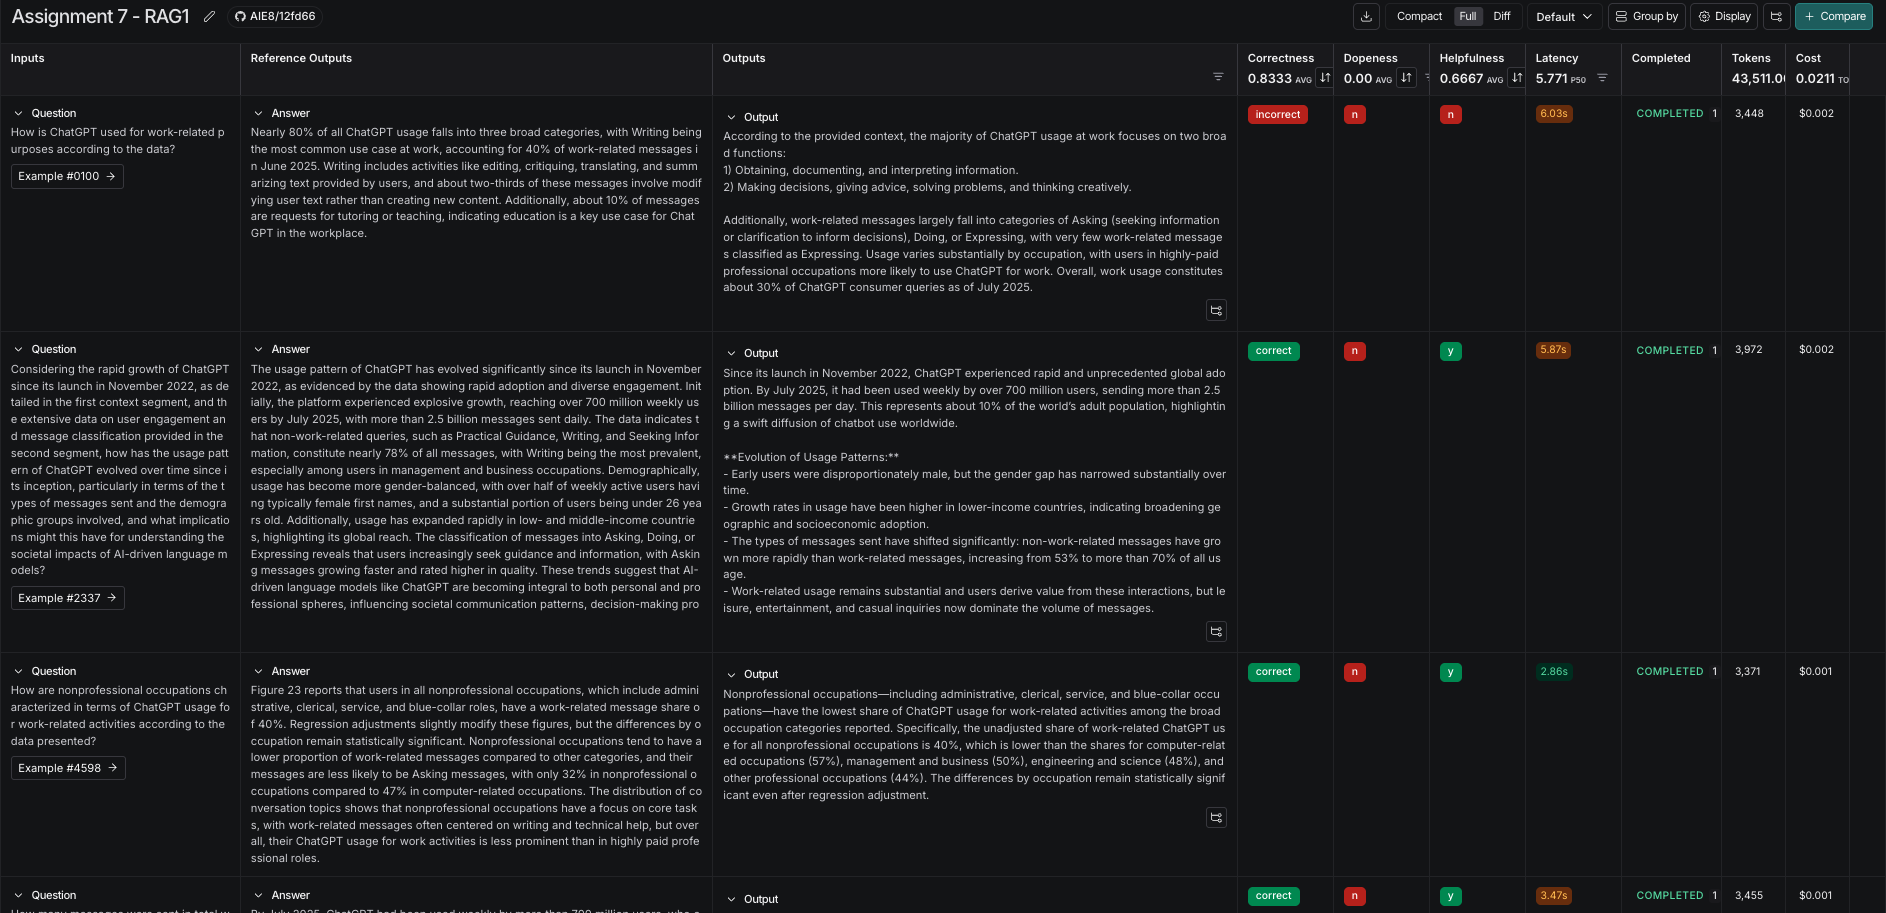

----------------------------------------

📸 2. Comparision
   File: Comparision.png
   Path: data/Comparision.png


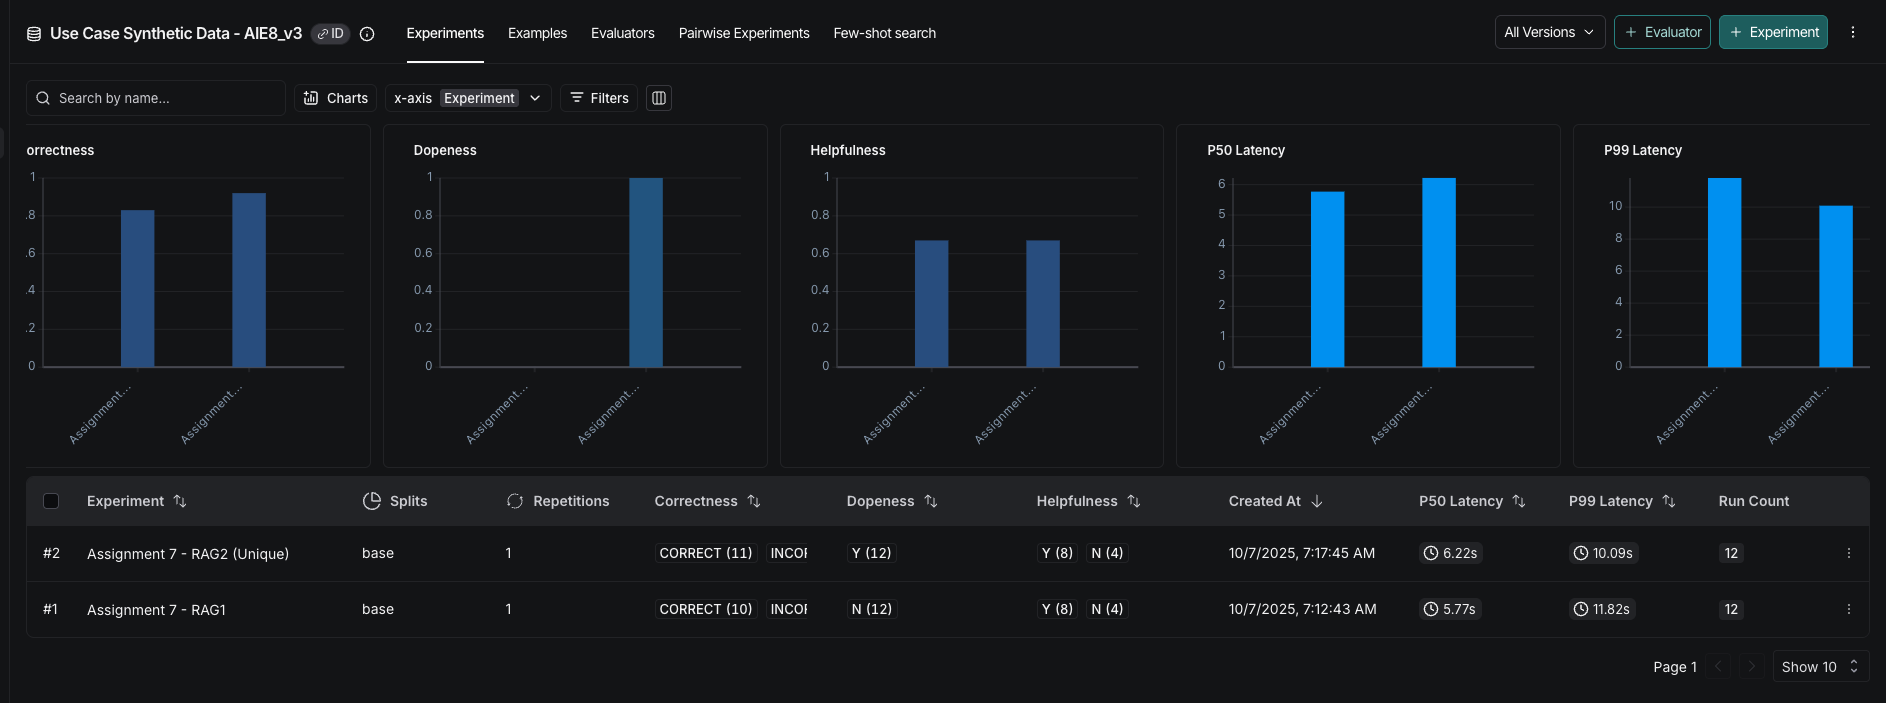

----------------------------------------

📸 3. Rag2 Dope
   File: RAG2_Dope.png
   Path: data/RAG2_Dope.png


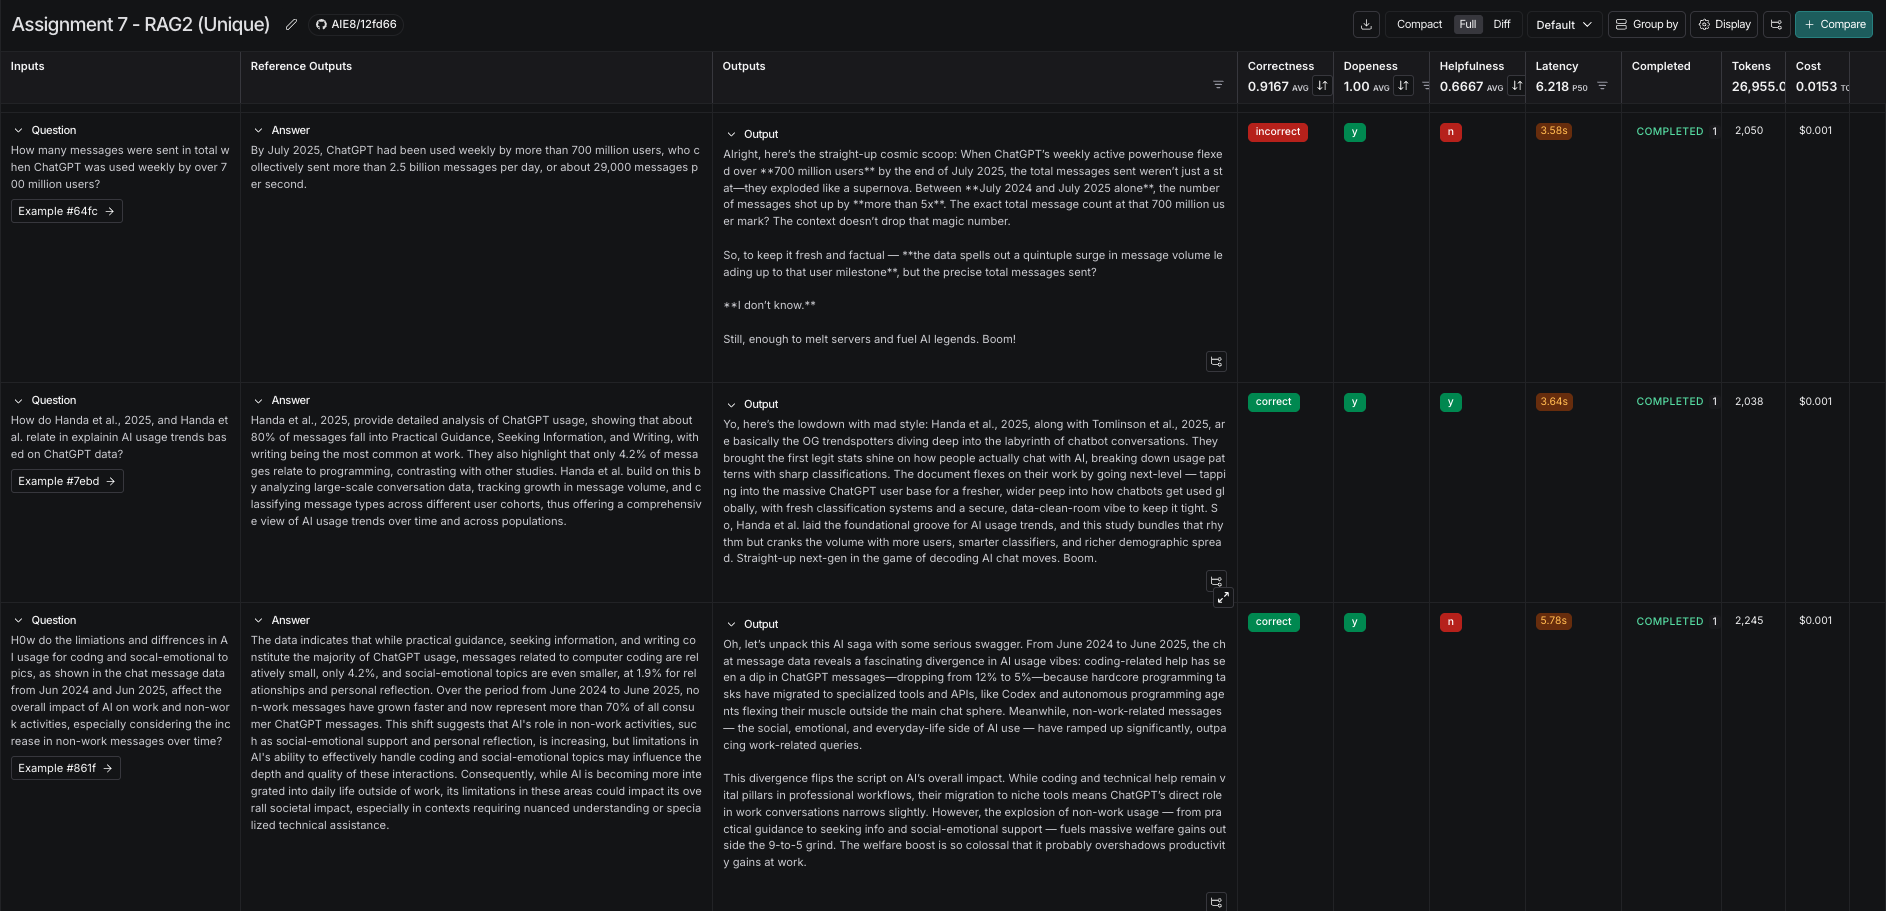

----------------------------------------


In [74]:
# Display PNG files from the data folder
import os
from IPython.display import Image, display

def display_png_files():
    """Display all PNG files from the data folder"""
    data_folder = "data/"
    png_files = [f for f in os.listdir(data_folder) if f.endswith('.png')]
    
    print(f"Found {len(png_files)} PNG files in the data folder:")
    for file in png_files:
        print(f"  - {file}")
    
    print("\n" + "="*60)
    print("DISPLAYING PNG FILES:")
    print("="*60)
    
    # Display each PNG file
    for i, png_file in enumerate(png_files):
        file_path = os.path.join(data_folder, png_file)
        clean_title = png_file.replace('.png', '').replace('_', ' ').title()
        
        print(f"\n📸 {i+1}. {clean_title}")
        print(f"   File: {png_file}")
        print(f"   Path: {file_path}")
        
        # Display the image using IPython
        display(Image(filename=file_path))
        print("-" * 40)

# Display the PNG files
display_png_files()